In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
from IPython.display import display, HTML
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error, auc, roc_curve, roc_auc_score
from decimal import Decimal
import geopandas as gpd
from shapely.geometry import Point
from scipy.interpolate import griddata
import rasterio
from rasterio.transform import from_origin

# Get multiple outputs in the same cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Ignore all warnings
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings(action='ignore', category=DeprecationWarning)
pd.set_option('display.max_columns', None)

## Data preparation

In [4]:
# Read in the data 
# We have two dataframes with same column but different data 
# I believe we should have one dataframe contain information about both dataframes (presence and absence)

# Here below we are reading the standardised dataframes
# presence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_training/standardised_points_of_presence.csv', delimiter=';')
# absence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_training/standardised_points_of_absence.csv', delimiter=';')

presence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_training/points_of_presence_test_new.csv', delimiter=';')
absence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_training/points_of_absence_test_new.csv', delimiter=';')

print("Presence info", presence_df.shape)
print("Absence info", absence_df.shape)

Presence info (46110, 26)
Absence info (46110, 26)


In [5]:
# Head for points of presence data
print("Points of presence")
presence_df.head()

# Head for points of absence data
print("Points of absence")
absence_df.head()

Points of presence


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,"19,552906066300000","-33,503039127100003","423,8035889","1262675,2500000","7,6203117","11,7305155","21,6820641","155,2328949","294957,0312500","0,1973951","15,9867964","9,6832962","23,0573425","204,5053253","1866,6802979","9051,3925781","262,1053772","754,4794922","579,4953003","122,6880951","67,2119293","123,3386612","0,3997020","0,0000000","0,0000000"
1,2,"19,554065257300000","-33,502591599200002","418,8850098","1238057,0000000","7,5433488","13,2344179","24,5836411","151,8608856","295034,0312500","0,1286995","15,8695059","9,6180811","22,8775139","206,5435181","1837,9093018","9064,5273438","255,0745544","753,3905029","596,1103516","122,8667297","67,3483429","124,2754517","0,4077038","0,0000000","0,0000000"
2,3,"19,553220609499999","-33,504088723999999","408,7989197","1293872,6250000","7,6285295","9,4727755","17,4985867","153,0930939","294792,1250000","0,1446818","16,0426788","9,7182827","23,1365280","204,9259338","1879,4543457","9633,4052734","271,9782715","760,3276978","598,3022461","121,0519714","66,8941498","119,2392654","0,4207691","0,0000000","0,0000000"
3,4,"19,554527855100002","-33,504862308200003","393,0697327","1312602,2500000","7,5401411","7,9924750","14,8219433","147,5858154","294676,7812500","0,0504019","16,0228729","9,7115231","23,0989895","207,0958252","1873,5273438","10316,7373047","279,1886597","766,2723389","630,4938965","119,1085968","66,6778259","115,3868942","0,4456471","0,0000000","0,0000000"
4,5,"19,553802071600000","-33,504471387300001","400,9482727","1303012,5000000","7,5930171","8,7492332","16,1888485","150,6344604","294734,6562500","0,0999071","16,0353279","9,7162180","23,1218605","205,8853760","1877,1494141","9953,2421875","275,1390381","763,1566162","614,1897583","120,1982269","66,7786255","117,3420486","0,4328750","0,0000000","0,0000000"


Points of absence


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,"21,568219575073385","-32,845436310137586","667,1586914","1483005,1250000","9,0135527","2,1335182","3,4945560","134,8665924","297321,6562500","-0,0866669","18,6504345","11,5633831","26,4917850","40,3150101","2625,9384766","1005,2607422","52,6314621","693,5087891","46,7836609","138,2878418","74,7023392","168,2033691","0,0878413","0,0240000","0,0480000"
1,2,"19,929761337216007","-34,669140494937835","17,7988892","1334560,0000000","8,8747396","1,1062130","1,7273655","152,5726471","27658,9550781","-0,0117142","18,1583271","13,7313309","23,9642906","231,7956696","2157,1762695","4419,1899414","245,2176666","639,4815674","445,3425293","193,3942566","69,1715851","167,1241913","0,2856699","0,0037139","0,0037139"
2,3,"20,853933888937888","-33,715715851505308","487,1492310","1444049,5000000","7,2310748","2,3288376","4,0689297","131,4290314","225323,4218750","-0,0191663","17,1582813","10,4304876","25,2325687","118,7681351","2206,4777832","1042,4602051","178,8755035","651,9295044","232,8902435","191,7061310","77,0000000","156,5092010","0,1098227","0,0339411","0,0480000"
3,4,"19,913425410354478","-33,069432348823796","595,4059448","1477565,2500000","8,2927780","1,5052947","2,0903606","157,0732117","388392,0000000","-0,0615444","17,6923790","10,1807861","26,0774708","39,0124130","2364,7324219","1129,3968506","68,1352386","713,8799438","87,1456985","150,1565552","80,7177124","135,9635010","0,1504509","0,0291952","0,0000000"
4,5,"21,591854189219532","-32,879877811112067","677,4995728","1508521,2500000","7,9686489","2,6092782","4,5575848","294,1683960","296658,8750000","0,0365601","18,5143147","11,5140390","26,2532215","39,0649796","2588,6350098","997,8342285","49,6851540","705,8392944","27,6697407","126,7174072","73,2194366","167,4905548","0,0906056","0,0008665","0,0378356"


In [6]:
# Check for Null values 
print("Null result for presence")
presence_df.isnull().sum()

print("Null results for absence")
absence_df.isnull().sum()

# Interesting with the standardised data there are no null values 
# PS standardised the data using fuzzy membership functions linear membership function 

Null result for presence


OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                2
sudem_1000m_albers_curvature_wc                   2
composite_temp_mean_1000m_k30_wc                  4
composite_temp_min_1000m_k30_wc                   4
composite_temp_max_1000m_k30_wc                   4
composite_rainfall_sum_1000m_k30_wc               2
composite_gdd_grapes_1000m_wc                     4
composite_AETI_1000m_albers_wc                    0
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

Null results for absence


OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_k30_wc                  1
composite_temp_min_1000m_k30_wc                   1
composite_temp_max_1000m_k30_wc                   1
composite_rainfall_sum_1000m_k30_wc               0
composite_gdd_grapes_1000m_wc                     1
composite_AETI_1000m_albers_wc                    2
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

In [7]:
# Forgot to name the rainfall column correctly, I need to rename it
presence_df.rename(columns={'composite_rainfall_sum_1000m_albers_k30_wc_fuzzy_linear_1':'composite_rainfall_sum_1000m_albers_k30_wc_fuzzy_linear'}, inplace=True)

In [7]:
# Adding suitability column to both df and assigning a value of 1 to where there vineyards and 0 where there are no vineyards

presence_df['suitability'] = 1  # Highly suitable (characteristics for suitable vineyards)
absence_df['suitability'] = 0  # Less suitable (characteristics for potential suitability/ non suitability)

# Checking size of the dataframes
print("Checking size of the dataframes")
presence_df['suitability'].value_counts()
absence_df['suitability'].value_counts()

Checking size of the dataframes


suitability
1    46110
Name: count, dtype: int64

suitability
0    46110
Name: count, dtype: int64

In [8]:
# Combine the datasets
# other combining functions include merge() join()
# combined_df = pd.concat([presence_df, absence_df], axis=0) (This concatinates my df as strings which resulted in some values being Nan, results in twice as many points)

# merge function combines the df using a common column and then renames columns that were same using x o y suffixes 
# results in 46110 points (original value)
# creates separate column called suitability_x and suitability_y 
# concatinating the df vertically and axis=0 adds rows, axis = 1 adds columns

combined_df = pd.concat([presence_df, absence_df], axis=0, ignore_index=True)

print("combined dataframe")
combined_df


combined dataframe


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
0,1,"19,552906066300000","-33,503039127100003","423,8035889","1262675,2500000","7,6203117","11,7305155","21,6820641","155,2328949","294957,0312500","0,1973951","15,9867964","9,6832962","23,0573425","204,5053253","1866,6802979","9051,3925781","262,1053772","754,4794922","579,4953003","122,6880951","67,2119293","123,3386612","0,3997020","0,0000000","0,0000000",1
1,2,"19,554065257300000","-33,502591599200002","418,8850098","1238057,0000000","7,5433488","13,2344179","24,5836411","151,8608856","295034,0312500","0,1286995","15,8695059","9,6180811","22,8775139","206,5435181","1837,9093018","9064,5273438","255,0745544","753,3905029","596,1103516","122,8667297","67,3483429","124,2754517","0,4077038","0,0000000","0,0000000",1
2,3,"19,553220609499999","-33,504088723999999","408,7989197","1293872,6250000","7,6285295","9,4727755","17,4985867","153,0930939","294792,1250000","0,1446818","16,0426788","9,7182827","23,1365280","204,9259338","1879,4543457","9633,4052734","271,9782715","760,3276978","598,3022461","121,0519714","66,8941498","119,2392654","0,4207691","0,0000000","0,0000000",1
3,4,"19,554527855100002","-33,504862308200003","393,0697327","1312602,2500000","7,5401411","7,9924750","14,8219433","147,5858154","294676,7812500","0,0504019","16,0228729","9,7115231","23,0989895","207,0958252","1873,5273438","10316,7373047","279,1886597","766,2723389","630,4938965","119,1085968","66,6778259","115,3868942","0,4456471","0,0000000","0,0000000",1
4,5,"19,553802071600000","-33,504471387300001","400,9482727","1303012,5000000","7,5930171","8,7492332","16,1888485","150,6344604","294734,6562500","0,0999071","16,0353279","9,7162180","23,1218605","205,8853760","1877,1494141","9953,2421875","275,1390381","763,1566162","614,1897583","120,1982269","66,7786255","117,3420486","0,4328750","0,0000000","0,0000000",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92215,46106,"23,495416236370261","-31,793901584990124","1162,4739990","1597666,8750000","9,1995277","1,0253339","0,8319384","133,0602570","411619,1250000","-0,0163932","16,7675591","9,2552242","24,7319012","154,0359039","2195,5539551","1137,9976807","63,1911736","599,7850342","71,1006393","203,1139832","80,7703247","197,1394501","0,1382415","0,0000000","0,0480000",0
92216,46107,"22,715602905349840","-31,872963273935909","1323,8831787","1618685,0000000","9,0564175","0,4957476","0,8652785","115,7642212","452081,5625000","0,0332791","16,4653759","10,1061459","23,1868896","73,6929855","2037,0895996","1219,7507324","67,8278656","607,3751831","68,1308975","183,7181549","78,4343643","208,9066467","0,1322167","0,0034267","0,0034267",0
92217,46108,"22,474740777764737","-31,765556181672423","1554,3348389","1665689,3750000","7,5474143","1,6631688","2,9036171","149,8292694","478055,4375000","-0,0227279","15,5771427","9,6843328","21,7293301","53,4433708","1825,0356445","1559,5961914","73,2299728","597,6461792","62,1008034","180,7212372","77,8456345","221,6186066","0,1539931","0,0453529","0,0138854",0
92218,46109,"23,662031286414788","-31,911282061617783","1131,0124512","1599360,2500000","8,4490862","1,8949413","3,2963638","337,2799683","397868,5312500","0,0661309","16,7568569","8,8685846","

In [9]:
# Remove NDVI, ROADS and RIVERS from the combined dataframe
# NDVI might be leading to some bias in the model
# ROADS and RIVERS are not important for the model

# The points that are standardised do not have ndvi_wc, euclidean_distance_roads_1000m_albers_wc, euclidean_distance_rivers_1000m_albers_wc

combined_df = combined_df.drop(['ndvi_wc', 'euclidean_distance_roads_1000m_albers_wc', 'euclidean_distance_rivers_1000m_albers_wc'], axis=1) 


In [10]:
# Data types of the columns before conversion
combined_df.dtypes

OID_                                               int64
POINT_X                                           object
POINT_Y                                           object
sudem_1000m_albers_filled_wc                      object
sudem_1000m_albers_potential_solar_rad_wh2m_wc    object
sudem_1000m_albers_twi_d8_wc                      object
sudem_1000m_albers_slope_degree_wc                object
sudem_1000m_albers_slope_wc                       object
sudem_1000m_albers_aspect_wc                      object
sudem_1000m_albers_flow_network_wc                object
sudem_1000m_albers_curvature_wc                   object
composite_temp_mean_1000m_k30_wc                  object
composite_temp_min_1000m_k30_wc                   object
composite_temp_max_1000m_k30_wc                   object
composite_rainfall_sum_1000m_k30_wc               object
composite_gdd_grapes_1000m_wc                     object
composite_AETI_1000m_albers_wc                    object
nitrogen_0_to_5cm_1000m_albers_

In [11]:
# Remove commas from the values and convert to float/double
# removed the following columns from the list: 'ndvi_wc', 'euclidean_distance_roads_1000m_albers_wc', 'euclidean_distance_rivers_1000m_albers_wc'
def clean_and_convert(x):
    return x.str.replace(',', '.').astype('float')

# This is for the non-standardised data
columns_to_convert = ['POINT_X', 'POINT_Y', 'sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
                        'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc', 'sudem_1000m_albers_slope_wc',
                        'sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
                        'composite_temp_mean_1000m_k30_wc', 'composite_temp_min_1000m_k30_wc', 'composite_temp_max_1000m_k30_wc',
                        'composite_rainfall_sum_1000m_k30_wc', 'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc',
                        'nitrogen_0_to_5cm_1000m_albers_wc', 'sand_0_to_5cm_1000m_albers_wc', 'soc_0_to_5cm_1000m_albers_wc',
                        'clay_content_0_to_5cm_1000m_albers_wc', 'soil_ph_0_to_5cm_1000m_albers_wc', 'silt_0_to_5cm_1000m_albers_wc'] 

# This is for the standardised data
# Note that the rainfall variable might be different from the non-standardised data (the other contains albers in the name and the other does not)
# columns_to_convert = ['POINT_X', 'POINT_Y', 'sudem_1000m_albers_filled_wc_fuzzy_linear', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear',
#                         'sudem_1000m_albers_twi_d8_wc_fuzzy_linear', 'sudem_1000m_albers_slope_degree_wc_fuzzy_linear', 'sudem_1000m_albers_slope_wc_fuzzy_linear',
#                         'sudem_1000m_albers_aspect_wc_fuzzy_linear', 'sudem_1000m_albers_flow_network_wc_fuzzy_linear', 'sudem_1000m_albers_curvature_wc_fuzzy_linear',
#                         'composite_temp_mean_1000m_k30_wc_fuzzy_linear', 'composite_temp_min_1000m_k30_wc_fuzzy_linear', 'composite_temp_max_1000m_k30_wc_fuzzy_linear',
#                         'composite_rainfall_sum_1000m_k30_wc_fuzzy_linear', 'composite_gdd_grapes_1000m_wc_fuzzy_linear', 'composite_AETI_1000m_albers_wc_fuzzy_linear',
#                         'nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'sand_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'soc_0_to_5cm_1000m_albers_wc_fuzzy_linear',
#                         'clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'silt_0_to_5cm_1000m_albers_wc_fuzzy_linear']

for col in columns_to_convert:
    combined_df[col] = clean_and_convert(combined_df[col])

In [12]:
# Data types of the columns after conversion
combined_df.dtypes

OID_                                                int64
POINT_X                                           float64
POINT_Y                                           float64
sudem_1000m_albers_filled_wc                      float64
sudem_1000m_albers_potential_solar_rad_wh2m_wc    float64
sudem_1000m_albers_twi_d8_wc                      float64
sudem_1000m_albers_slope_degree_wc                float64
sudem_1000m_albers_slope_wc                       float64
sudem_1000m_albers_aspect_wc                      float64
sudem_1000m_albers_flow_network_wc                float64
sudem_1000m_albers_curvature_wc                   float64
composite_temp_mean_1000m_k30_wc                  float64
composite_temp_min_1000m_k30_wc                   float64
composite_temp_max_1000m_k30_wc                   float64
composite_rainfall_sum_1000m_k30_wc               float64
composite_gdd_grapes_1000m_wc                     float64
composite_AETI_1000m_albers_wc                    float64
nitrogen_0_to_

In [13]:
# Describe the data and check for nulls again

combined_df.describe()
# combined_df.head(10)
combined_df['suitability'].value_counts()

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,suitability
count,92220.000000,92220.000000,92220.000000,92220.000000,9.222000e+04,92220.000000,92220.000000,92220.000000,92220.000000,92218.000000,92218.000000,92215.000000,92215.000000,92215.000000,92218.000000,92215.000000,92218.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000
mean,23055.500000,19.911518,-33.252359,410.186418,1.418921e+06,8.022344,5.848445,10.526389,183.956392,195589.543491,0.001042,17.253188,11.406758,24.188069,227.269529,2149.435938,4743.151560,208.959731,715.950744,336.835294,139.967260,67.839283,125.306119,0.500000
std,13310.882622,1.435040,0.826937,360.676613,8.119734e+04,1.695695,6.348223,12.483488,73.886220,119431.143639,0.166475,1.175132,1.230188,1.721300,176.797435,278.469884,2511.117743,90.747868,103.970420,167.889763,43.894107,9.280704,41.279775,0.500003
min,1.000000,17.842223,-34.791018,0.799565,7.840468e+05,2.934461,0.014561,0.000000,1.825276,756.470093,-3.864582,10.221187,5.271195,14.986521,19.185396,619.879334,208.368652,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11528.000000,18.855983,-33.834191,159.926044,1.377091e+06,7.006381,1.791921,2.958823,129.001457,75449.628906,-0.052711,16.741623,10.697241,23.194470,93.026997,2011.494324,2678.495728,129.124641,662.437058,204.204910,104.861471,63.268241,94.866283,0.000000
50%,23055.500000,19.347553,-33.558733,258.975861,1.400370e+06,7.782132,3.464592,5.995954,185.871468,209083.507812,-0.001051,17.378757,11.513188,24.464731,175.376473,2189.730225,4762.085938,227.240799,729.614655,351.578049,132.793838,67.554493,125.713940,0.500000
75%,34583.000000,20.660675,-32.815619,597.993195,1.456098e+06,8.706856,7.371059,13.003455,240.100498,288047.617188,0.050114,17.974816,12.479805,25.308208,305.785057,2318.544434,6680.186523,276.138100,790.963394,464.928406,174.714436,74.478222,152.361034,1.000000
max,46110.000000,24.163170,-30.459279,2139.788330,1.842116e+06,25.779661,57.476253,159.018570,358.531403,501485.750000,4.648477,19.867142,13.864833,28.243813,2071.323242,2853.351318,13430.311523,502.066894,878.233643,1075.480835,313.768738,87.000000,345.055420,1.000000


suitability
1    46110
0    46110
Name: count, dtype: int64

In [14]:
# check for null in the combined_df
print("Null values before dropping")
combined_df.shape
combined_df.isnull().sum()
combined_df.dropna(inplace=True)
print("Null values after dropping")
combined_df.shape
combined_df.isnull().sum()

Null values before dropping


(92220, 24)

OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                2
sudem_1000m_albers_curvature_wc                   2
composite_temp_mean_1000m_k30_wc                  5
composite_temp_min_1000m_k30_wc                   5
composite_temp_max_1000m_k30_wc                   5
composite_rainfall_sum_1000m_k30_wc               2
composite_gdd_grapes_1000m_wc                     5
composite_AETI_1000m_albers_wc                    2
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

Null values after dropping


(92213, 24)

OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_k30_wc                  0
composite_temp_min_1000m_k30_wc                   0
composite_temp_max_1000m_k30_wc                   0
composite_rainfall_sum_1000m_k30_wc               0
composite_gdd_grapes_1000m_wc                     0
composite_AETI_1000m_albers_wc                    0
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

In [15]:
# sort the dataframes by POINT_X and POINT_Y
combined_df = combined_df.sort_values(by=['POINT_X', 'POINT_Y'])

In [16]:
combined_df

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,suitability
88805,42696,17.842223,-31.092680,172.032547,1446455.000,8.559930,1.332115,2.302083,282.782105,12579.391602,-0.039437,18.211512,13.086869,24.443161,23.492949,2150.921875,1088.019898,95.183228,763.351868,231.830765,131.982803,75.000000,104.665314,0
89145,43036,17.847598,-31.142158,121.793091,1437265.000,11.516044,0.510896,0.891735,260.428497,9141.754883,-0.010545,18.324986,13.154163,24.616901,24.394709,2177.283691,818.780823,99.691078,739.801636,245.586182,135.382660,77.091911,124.781982,0
88892,42783,17.848675,-31.192200,82.575783,1427648.750,9.944447,1.111513,1.940225,250.937820,4899.702148,-0.016449,18.352282,13.179053,24.644382,25.483866,2181.080078,1083.154053,114.760010,738.753418,198.292496,133.001511,76.958816,128.421616,0
90269,44160,17.856287,-31.134076,139.282974,1437422.500,10.066491,1.445921,2.524232,241.154190,10683.605469,0.072123,18.284254,13.123871,24.563217,24.477837,2168.239502,732.360168,100.003105,719.665283,238.487915,161.453735,77.569092,118.100815,0
89928,43819,17.861519,-31.208286,111.086571,1429745.500,8.968467,1.739554,3.035772,229.335846,6184.509766,0.053375,18.301386,13.147077,24.567514,26.253515,2167.834961,1492.649048,118.835258,733.534302,195.166275,136.728302,76.470863,129.983551,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85674,39565,24.141927,-31.977841,1693.106201,1685273.875,6.826403,7.745956,13.632985,83.079071,288086.593750,-0.065672,13.785381,7.649215,20.238836,189.760086,1477.586426,3446.857666,149.797653,545.025818,156.837433,224.241119,72.482155,230.733093,0
85333,39224,24.142348,-31.971373,1637.564453,1758190.375,7.920777,10.911353,19.280811,11.736856,170854.031250,-0.151414,13.774164,7.640666,20.223969,189.874374,1475.689819,3410.915039,143.322525,542.705627,147.901474,225.660584,73.127831,231.633774,0
86102,39993,24.149071,-31.981486,1621.015747,1655597.375,8.528321,2.376466,4.139143,112.903915,221581.875000,0.018215,14.048969,7.808098,20.635817,187.915100,1539.027832,3685.477539,150.239044,548.953552,225.520065,227.819275,73.660194,223.227158,0
92069,45960,24.162493,-31.932255,1527.335571,1685165.875,6.792073,1.623480,2.834443,48.230461,165712.718750,0.025140,14.598185,8.110333,21.492310,189.604981,1674.374878,2808.190918,118.419663,518.034790,105.113350,231.318726,73.000000,249.845581,0


In [17]:
# Try to use interpolation to fill the null values after converting the columns to float
# Interpolation is done based on the surrounding values in the column
# add the columns that have null values to the list below

# No interpolation was needed for the standardised data since there were no null values

columns_to_interpolate = ['sudem_1000m_albers_curvature_wc', 'sudem_1000m_albers_flow_network_wc',
                        'composite_temp_mean_1000m_k30_wc','composite_temp_min_1000m_k30_wc',
                        'composite_temp_max_1000m_k30_wc', 'composite_rainfall_sum_1000m_k30_wc',
                        'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc']


def interpolate_columns(df, columns):
    for col in columns:
        df[col].interpolate(method='linear', inplace=True)
    return df

interpolate_columns(combined_df, columns_to_interpolate)

# check again for nulls
combined_df.isnull().sum()

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,suitability
88805,42696,17.842223,-31.092680,172.032547,1446455.000,8.559930,1.332115,2.302083,282.782105,12579.391602,-0.039437,18.211512,13.086869,24.443161,23.492949,2150.921875,1088.019898,95.183228,763.351868,231.830765,131.982803,75.000000,104.665314,0
89145,43036,17.847598,-31.142158,121.793091,1437265.000,11.516044,0.510896,0.891735,260.428497,9141.754883,-0.010545,18.324986,13.154163,24.616901,24.394709,2177.283691,818.780823,99.691078,739.801636,245.586182,135.382660,77.091911,124.781982,0
88892,42783,17.848675,-31.192200,82.575783,1427648.750,9.944447,1.111513,1.940225,250.937820,4899.702148,-0.016449,18.352282,13.179053,24.644382,25.483866,2181.080078,1083.154053,114.760010,738.753418,198.292496,133.001511,76.958816,128.421616,0
90269,44160,17.856287,-31.134076,139.282974,1437422.500,10.066491,1.445921,2.524232,241.154190,10683.605469,0.072123,18.284254,13.123871,24.563217,24.477837,2168.239502,732.360168,100.003105,719.665283,238.487915,161.453735,77.569092,118.100815,0
89928,43819,17.861519,-31.208286,111.086571,1429745.500,8.968467,1.739554,3.035772,229.335846,6184.509766,0.053375,18.301386,13.147077,24.567514,26.253515,2167.834961,1492.649048,118.835258,733.534302,195.166275,136.728302,76.470863,129.983551,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85674,39565,24.141927,-31.977841,1693.106201,1685273.875,6.826403,7.745956,13.632985,83.079071,288086.593750,-0.065672,13.785381,7.649215,20.238836,189.760086,1477.586426,3446.857666,149.797653,545.025818,156.837433,224.241119,72.482155,230.733093,0
85333,39224,24.142348,-31.971373,1637.564453,1758190.375,7.920777,10.911353,19.280811,11.736856,170854.031250,-0.151414,13.774164,7.640666,20.223969,189.874374,1475.689819,3410.915039,143.322525,542.705627,147.901474,225.660584,73.127831,231.633774,0
86102,39993,24.149071,-31.981486,1621.015747,1655597.375,8.528321,2.376466,4.139143,112.903915,221581.875000,0.018215,14.048969,7.808098,20.635817,187.915100,1539.027832,3685.477539,150.239044,548.953552,225.520065,227.819275,73.660194,223.227158,0
92069,45960,24.162493,-31.932255,1527.335571,1685165.875,6.792073,1.623480,2.834443,48.230461,165712.718750,0.025140,14.598185,8.110333,21.492310,189.604981,1674.374878,2808.190918,118.419663,518.034790,105.113350,231.318726,73.000000,249.845581,0


OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_k30_wc                  0
composite_temp_min_1000m_k30_wc                   0
composite_temp_max_1000m_k30_wc                   0
composite_rainfall_sum_1000m_k30_wc               0
composite_gdd_grapes_1000m_wc                     0
composite_AETI_1000m_albers_wc                    0
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

In [18]:
combined_df.head(10)
combined_df.describe()

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,suitability
88805,42696,17.842223,-31.092680,172.032547,1446455.000,8.559930,1.332115,2.302083,282.782105,12579.391602,-0.039437,18.211512,13.086869,24.443161,23.492949,2150.921875,1088.019898,95.183228,763.351868,231.830765,131.982803,75.000000,104.665314,0
89145,43036,17.847598,-31.142158,121.793091,1437265.000,11.516044,0.510896,0.891735,260.428497,9141.754883,-0.010545,18.324986,13.154163,24.616901,24.394709,2177.283691,818.780823,99.691078,739.801636,245.586182,135.382660,77.091911,124.781982,0
88892,42783,17.848675,-31.192200,82.575783,1427648.750,9.944447,1.111513,1.940225,250.937820,4899.702148,-0.016449,18.352282,13.179053,24.644382,25.483866,2181.080078,1083.154053,114.760010,738.753418,198.292496,133.001511,76.958816,128.421616,0
90269,44160,17.856287,-31.134076,139.282974,1437422.500,10.066491,1.445921,2.524232,241.154190,10683.605469,0.072123,18.284254,13.123871,24.563217,24.477837,2168.239502,732.360168,100.003105,719.665283,238.487915,161.453735,77.569092,118.100815,0
89928,43819,17.861519,-31.208286,111.086571,1429745.500,8.968467,1.739554,3.035772,229.335846,6184.509766,0.053375,18.301386,13.147077,24.567514,26.253515,2167.834961,1492.649048,118.835258,733.534302,195.166275,136.728302,76.470863,129.983551,0
88789,42680,17.862257,-31.206683,113.849335,1429046.125,8.982673,2.076754,3.625584,210.140640,6878.145996,0.050721,18.294790,13.142599,24.558380,26.260151,2166.342529,1426.104858,119.144165,731.328003,196.022736,139.675949,76.304833,129.267410,0
88549,42440,17.863457,-31.134243,146.319672,1431277.875,8.289036,1.942830,3.392428,207.916855,11382.222656,0.050254,18.217009,13.081001,24.464115,24.700293,2151.995117,693.267578,99.654266,723.127747,236.525726,165.454468,77.043663,111.318543,0
87508,41399,17.866460,-31.208978,108.887245,1427755.000,10.262574,1.767922,3.082549,179.130570,7323.974121,0.019845,18.230316,13.105438,24.458094,26.449686,2150.153564,1527.287964,125.159683,726.614624,187.776810,140.466904,76.537666,132.918457,0
88307,42198,17.871997,-31.117258,184.154465,1438485.125,8.877173,2.207613,3.856126,198.714356,20074.332031,-0.040791,18.130278,13.023280,24.339010,24.800198,2131.765625,732.940674,103.136917,724.474731,185.981659,164.095505,76.924713,111.331932,0
89858,43749,17.875215,-31.191513,106.080681,1424228.750,7.342710,1.561327,2.725821,171.299866,10668.773438,0.035666,18.251093,13.106255,24.507113,26.439217,2157.311768,822.520142,111.479691,708.696228,172.815659,174.380234,77.429863,116.923538,0


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,suitability
count,92213.000000,92213.000000,92213.000000,92213.000000,9.221300e+04,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000,92213.000000
mean,23054.793023,19.911584,-33.252408,410.215221,1.418924e+06,8.022182,5.848776,10.527000,183.953180,195599.989446,0.001041,17.253178,11.406721,24.188086,227.271835,2149.437595,4743.297840,208.968233,715.966501,336.848186,139.970181,67.840485,125.310171,0.499995
std,13310.722668,1.435002,0.826897,360.675088,8.119951e+04,1.695510,6.348342,12.483754,73.887401,119425.954981,0.166480,1.175143,1.230176,1.721314,176.798612,278.472472,2511.098239,90.744393,103.920026,167.885072,43.890846,9.275543,41.276738,0.500003
min,1.000000,17.842223,-34.791018,2.570186,7.840468e+05,2.934461,0.014561,0.000000,1.825276,1879.485840,-3.864582,10.221187,5.271195,14.986521,19.185396,619.879334,208.368652,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11528.000000,18.856076,-33.834186,159.951385,1.377092e+06,7.006313,1.792008,2.958971,128.998947,75500.398438,-0.052715,16.741608,10.697205,23.194443,93.030983,2011.495727,2678.603272,129.138870,662.448853,204.234192,104.861626,63.268242,94.869644,0.000000
50%,23054.000000,19.347642,-33.558760,258.985657,1.400373e+06,7.782120,3.464744,5.997303,185.862793,209093.640625,-0.001053,17.378689,11.513121,24.464806,175.376968,2189.739258,4762.132324,227.248993,729.616211,351.590027,132.793945,67.554428,125.719856,0.000000
75%,34582.000000,20.660691,-32.815842,598.018677,1.456104e+06,8.706489,7.373721,13.003816,240.097214,288053.625000,0.050119,17.974825,12.479786,25.308220,305.787537,2318.548096,6680.275391,276.140015,790.967346,464.937470,174.720245,74.478149,152.364243,1.000000
max,46110.000000,24.163170,-30.459279,2139.788330,1.842116e+06,25.779661,57.476253,159.018570,358.531403,501485.750000,4.648477,19.867142,13.864833,28.243813,2071.323242,2853.351318,13430.311523,502.066894,878.233643,1075.480835,313.768738,87.000000,345.055420,1.000000


## Data visualisation

In [69]:
# Distribution of target variable
# plt.figure(figsize=(8, 6))
# combined_df['suitability'].value_counts().plot(kind='bar')
# plt.title('Distribution of Target Variable')
# plt.xlabel('Target')
# plt.ylabel('Count')
# plt.show()

<Figure size 2000x1600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix of Features')

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5]),
 [Text(0.5, 0, 'sudem_1000m_albers_filled_wc'),
  Text(1.5, 0, 'sudem_1000m_albers_potential_solar_rad_wh2m_wc'),
  Text(2.5, 0, 'sudem_1000m_albers_twi_d8_wc'),
  Text(3.5, 0, 'sudem_1000m_albers_slope_degree_wc'),
  Text(4.5, 0, 'sudem_1000m_albers_slope_wc'),
  Text(5.5, 0, 'sudem_1000m_albers_aspect_wc'),
  Text(6.5, 0, 'sudem_1000m_albers_flow_network_wc'),
  Text(7.5, 0, 'sudem_1000m_albers_curvature_wc'),
  Text(8.5, 0, 'composite_temp_mean_1000m_k30_wc'),
  Text(9.5, 0, 'composite_temp_min_1000m_k30_wc'),
  Text(10.5, 0, 'composite_temp_max_1000m_k30_wc'),
  Text(11.5, 0, 'composite_rainfall_sum_1000m_k30_wc'),
  Text(12.5, 0, 'composite_gdd_grapes_1000m_wc'),
  Text(13.5, 0, 'composite_AETI_1000m_albers_wc'),
  Text(14.5, 0, 'nitrogen_0_to_5cm_1000m_albers_wc'),
  Text(15.5, 0, 'sand_0_to_5cm_1000m_albers_wc'),
  Text(16.5, 0, 'soc_0_to_5cm_

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5]),
 [Text(0, 0.5, 'sudem_1000m_albers_filled_wc'),
  Text(0, 1.5, 'sudem_1000m_albers_potential_solar_rad_wh2m_wc'),
  Text(0, 2.5, 'sudem_1000m_albers_twi_d8_wc'),
  Text(0, 3.5, 'sudem_1000m_albers_slope_degree_wc'),
  Text(0, 4.5, 'sudem_1000m_albers_slope_wc'),
  Text(0, 5.5, 'sudem_1000m_albers_aspect_wc'),
  Text(0, 6.5, 'sudem_1000m_albers_flow_network_wc'),
  Text(0, 7.5, 'sudem_1000m_albers_curvature_wc'),
  Text(0, 8.5, 'composite_temp_mean_1000m_k30_wc'),
  Text(0, 9.5, 'composite_temp_min_1000m_k30_wc'),
  Text(0, 10.5, 'composite_temp_max_1000m_k30_wc'),
  Text(0, 11.5, 'composite_rainfall_sum_1000m_k30_wc'),
  Text(0, 12.5, 'composite_gdd_grapes_1000m_wc'),
  Text(0, 13.5, 'composite_AETI_1000m_albers_wc'),
  Text(0, 14.5, 'nitrogen_0_to_5cm_1000m_albers_wc'),
  Text(0, 15.5, 'sand_0_to_5cm_1000m_albers_wc'),
  Text(0, 16.5, 'soc_0_to_5cm_

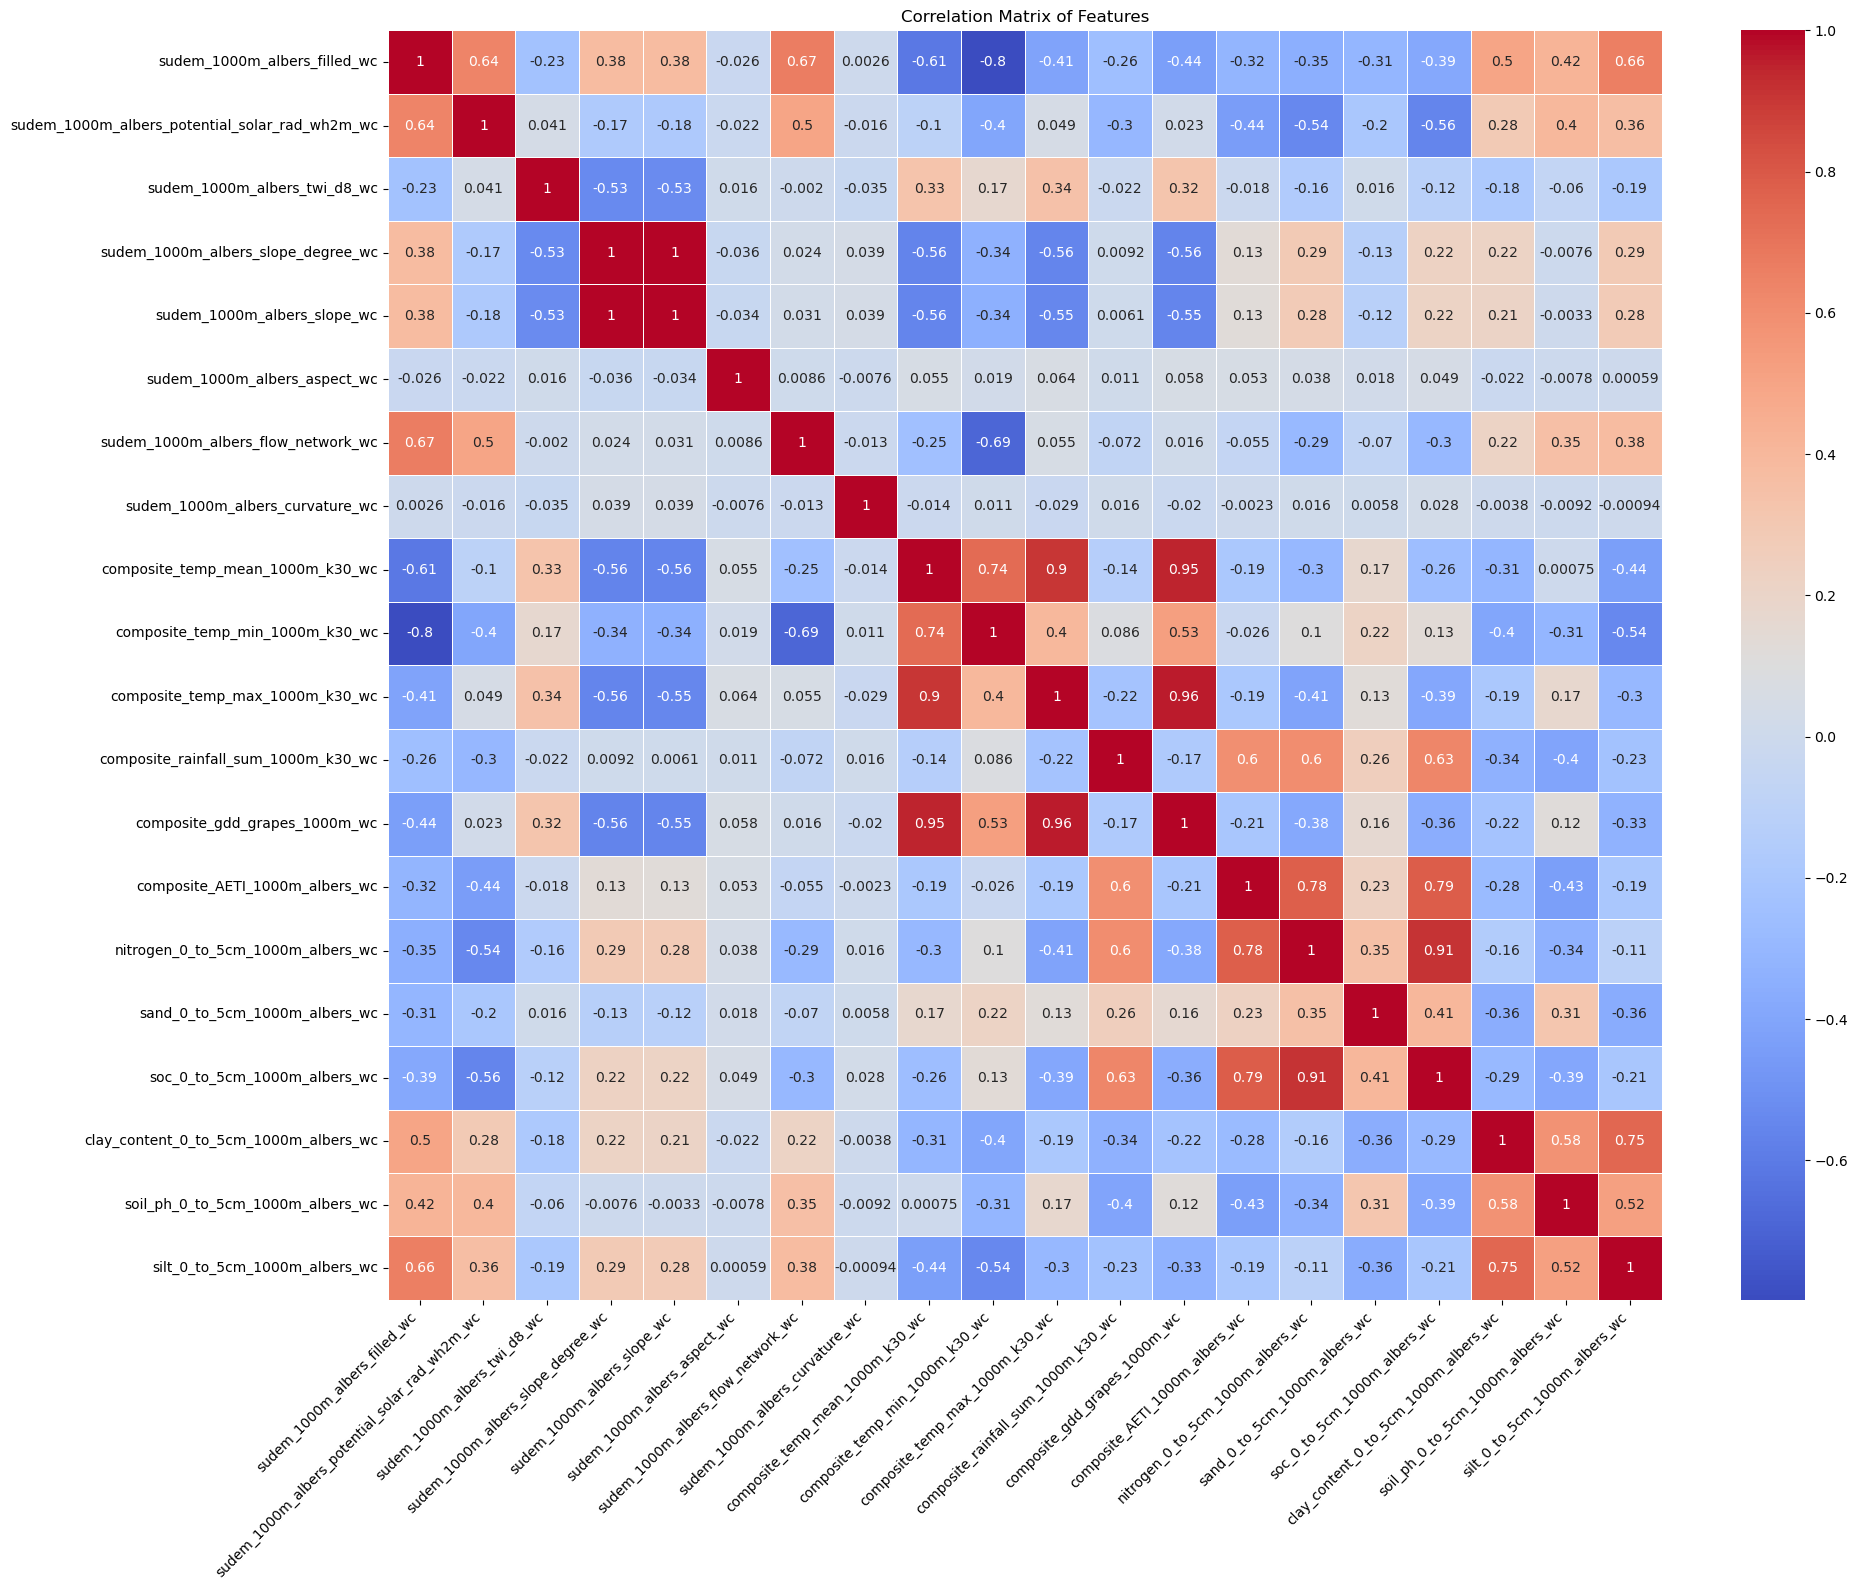

In [19]:
# Correlation matrix of features

# drop OID__, POINT_X, POINT_Y, suitability columns 
columns_to_drop = ['suitability', 'OID_', 'POINT_X', 'POINT_Y'] 
features = combined_df.drop(columns=columns_to_drop)

plt.figure(figsize=(20, 16))
correlation_matrix = features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[3:12], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

In [ ]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[12:21], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

In [ ]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[21:], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

In [ ]:
# Geographical distribution (if latitude and longitude are available)
plt.figure(figsize=(12, 8))
plt.scatter(combined_df[combined_df['suitability'] == 0]['POINT_X'], 
            combined_df[combined_df['suitability'] == 0]['POINT_Y'], 
            alpha=0.2, label='Absence')
plt.scatter(combined_df[combined_df['suitability'] == 1]['POINT_X'], 
            combined_df[combined_df['suitability'] == 1]['POINT_Y'], 
            alpha=0.2, label='Presence')
plt.title('Geographical Distribution of Points')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

## Model training

In [75]:
# I can potentially look at normalizing the data see the example below

# from sklearn.preprocessing import StandardScaler

# Normalizing 
# No need to normalize binary or Likert Scaled columns. 

# columns_to_normalize = df.columns[1:5] 

# Initialize the StandardScaler

# scaler = StandardScaler()

# Fit and transform the selected columns

# df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

In [ ]:
# This cell is applicable for the standardised data only
# Here I am dropping duplicates in my combined dataframe 
# I am doing this before splitting the data into training and testing sets

combined_df = combined_df.drop_duplicates()
combined_df.shape


In [20]:
# columns to drop
# I am dropping the suitability column because it is the target variable and OID column because it is an identifier and to reduce overfitting and noise 
# I can potentially drop the geometry columns as well?? 
# We can potentially drop POINT_X and POINT_Y because they are location identifiers rather than predictive features
# But if geographical location is important we can potentially keep them
columns_to_drop = ['suitability', 'OID_', 'POINT_X', 'POINT_Y'] 

# features/ predictor variables
X = combined_df.drop(columns=columns_to_drop)

# target variable (0 and 1)
y = combined_df['suitability']




In [21]:
# Create a train/test split with 20% as test size
# random_state controls the shuffling applied to the data before applying the split
# What does the value 42 signify now?
# What difference would it have made if I had use another value??
# I believe that 42 has been determined to be an optimal/default value for best model performance


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Scale the features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [22]:
# check for duplicates between training and test data (this checks for duplicates in the respective df)
# X_train.duplicated().sum()
# X_test.duplicated().sum()

# Create complete datasets for training and testing
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

train_data.shape
test_data.shape

# Check for duplicates between training and testing data
duplicates_df = pd.concat([train_data, test_data])
duplicates = pd.concat([train_data, test_data]).duplicated().sum()

duplicates_df.size

print(f"Number of duplicates between training and testing data: {duplicates}")

# to see the actual duplicate rows:
# duplicate_rows = pd.concat([train_data, test_data])[pd.concat([train_data, test_data]).duplicated(keep=False)]
# print("Duplicate rows:")
# print(duplicate_rows)

(73770, 21)

(18443, 21)

1936473

Number of duplicates between training and testing data: 0


In [23]:

# Initialize the XGBoost regressor
# There is also a XGBClassifier 
#  The XGBRegressor class in the XGBoost Python API is used for regression problems 

xgb_model = XGBRegressor(objective='reg:logistic', random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)



# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# accuracy = accuracy_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# print(y_pred[0:100])
# Model results without ndvi, roads, and rivers
# Mean Absolute Error: 0.0532
# Mean Squared Error: 0.0258
# R-squared Score: 0.8967


# Model results from using standardised data (although the data has duplicates 22792)
# Mean Absolute Error: 0.0574
# Mean Squared Error: 0.0271
# R-squared Score: 0.8915

# Model results from using standardised data after removing most the duplicates between traing and testing data (4444)
# Mean Absolute Error: 0.0573
# Mean Squared Error: 0.0269
# R-squared Score: 0.8924



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, objective='reg:logistic', ...)

Mean Absolute Error: 0.0546
Mean Squared Error: 0.0261
R-squared Score: 0.8956


## Predicting suitability for new locations

In [24]:
# Reading in points that have not been standardised and are ready for prediction
new_locations_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_predicting/wc_points_from_composite_raster.csv', delimiter=';')

# Reading the points that have been standardised and are ready for prediction
# new_locations_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_predicting/wc_points_from_composite_raster_standardised_data.csv', delimiter=';')

print("New locations", new_locations_df.shape)

New locations (129425, 26)


In [25]:
print("New locations")
new_locations_df.head()
new_locations_df.describe()
new_locations_df.shape

New locations


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,"17,881470420327695","-32,989886923320924","13,3591509","1388513,2500000","9,0873699","1,0365752","1,8093624","8,2484989",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1762,0593262","195,7058258","791,9479980","548,7803955","136,0110931","71,6226807","71,2295914",NaN,NaN,NaN
1,2,"17,891267569177280","-32,989916735369036","26,3872833","1379645,6250000","6,7358322","1,3606182","2,3751733","294,9450989","1884,5012207","0,0060949",NaN,NaN,NaN,"46,4888535",NaN,"1312,2176514","194,5019836","807,7775879","441,1436157","120,6417847","70,0415573","71,5074158","0,2276237","0,0000000","0,2173292"
2,3,"17,901064718274046","-32,989946506368661","24,4335155","1374516,1250000","7,7898469","3,3164825","5,7948275","283,4432373","4177,4809570","0,0285071","17,7508373","12,7455711","23,8823357","47,5113144","2101,8383789","923,9174194","189,8672791","803,2086182","328,5443726","112,3317642","69,2618790","84,5750732","0,2930189","0,0000000","0,2163700"
3,4,"17,910861867617651","-32,989976236319599","25,7099609","1369337,1250000","8,4178047","1,5184340","2,6507878","227,7552948","5973,5068359","0,0241457","17,6287670","12,6672115","23,7075596","48,5668983","2072,9357910","878,1225586","171,5429993","830,4109497","330,4615173","104,0151901","69,7064514","66,3746490","0,2734560","0,0000000","0,2160000"
4,5,"17,920659017207750","-32,990005925221347","49,1808815","1351664,0000000","6,7119193","5,5577383","9,7306213","244,1683197","6771,0859375","0,0282446","17,4997711","12,5845098","23,5222149","49,6198997","2042,3028564","1146,2939453","188,6783905","837,2388306","364,7166138","102,4696503","68,5765381","60,2915421","0,2729937","0,0000000","0,2160000"


,OID_
count,129425.000000
mean,64713.000000
std,37361.923632
min,1.000000
25%,32357.000000
50%,64713.000000
75%,97069.000000
max,129425.000000


(129425, 26)

In [26]:
new_locations_df.isnull().sum()

OID_                                                 0
POINT_X                                              0
POINT_Y                                              0
sudem_1000m_albers_filled_wc                      1976
sudem_1000m_albers_potential_solar_rad_wh2m_wc    2027
sudem_1000m_albers_twi_d8_wc                      1990
sudem_1000m_albers_slope_degree_wc                1990
sudem_1000m_albers_slope_wc                       1990
sudem_1000m_albers_aspect_wc                      1986
sudem_1000m_albers_flow_network_wc                2085
sudem_1000m_albers_curvature_wc                   2085
composite_temp_mean_1000m_k30_wc                  2343
composite_temp_min_1000m_k30_wc                   2343
composite_temp_max_1000m_k30_wc                   2343
composite_rainfall_sum_1000m_k30_wc               2177
composite_gdd_grapes_1000m_wc                     2343
composite_AETI_1000m_albers_wc                    2003
nitrogen_0_to_5cm_1000m_albers_wc                 2042
sand_0_to_

In [27]:
new_locations_df.dtypes

OID_                                               int64
POINT_X                                           object
POINT_Y                                           object
sudem_1000m_albers_filled_wc                      object
sudem_1000m_albers_potential_solar_rad_wh2m_wc    object
sudem_1000m_albers_twi_d8_wc                      object
sudem_1000m_albers_slope_degree_wc                object
sudem_1000m_albers_slope_wc                       object
sudem_1000m_albers_aspect_wc                      object
sudem_1000m_albers_flow_network_wc                object
sudem_1000m_albers_curvature_wc                   object
composite_temp_mean_1000m_k30_wc                  object
composite_temp_min_1000m_k30_wc                   object
composite_temp_max_1000m_k30_wc                   object
composite_rainfall_sum_1000m_k30_wc               object
composite_gdd_grapes_1000m_wc                     object
composite_AETI_1000m_albers_wc                    object
nitrogen_0_to_5cm_1000m_albers_

In [63]:
# Should not be necessary if i label my columns correctly from the start
new_locations_df.rename(columns={'composite_rainfall_sum_1000m_k30_wc_fuzzy_linear': 'composite_rainfall_sum_1000m_albers_k30_wc_fuzzy_linear'}, inplace=True)

In [28]:
# Drop ndvi, roads and rivers since the new model was trained without them
new_locations_df = new_locations_df.drop(['ndvi_wc', 'euclidean_distance_roads_1000m_albers_wc', 'euclidean_distance_rivers_1000m_albers_wc'], axis=1)

In [29]:
# Converting the columns to float

# This below is for the non-standardised data
columns_to_convert_for_new_locations = ['POINT_X','POINT_Y','sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
                        'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc', 'sudem_1000m_albers_slope_wc',
                        'sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
                        'composite_temp_mean_1000m_k30_wc','composite_temp_min_1000m_k30_wc', 'composite_temp_max_1000m_k30_wc',
                        'composite_rainfall_sum_1000m_k30_wc', 'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc',
                        'nitrogen_0_to_5cm_1000m_albers_wc', 'sand_0_to_5cm_1000m_albers_wc', 'soc_0_to_5cm_1000m_albers_wc',
                        'clay_content_0_to_5cm_1000m_albers_wc', 'soil_ph_0_to_5cm_1000m_albers_wc', 'silt_0_to_5cm_1000m_albers_wc']


# This below is for the standardised data
# columns_to_convert_for_new_locations = ['POINT_X', 'POINT_Y', 'sudem_1000m_albers_filled_wc_fuzzy_linear', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear',
#                         'sudem_1000m_albers_twi_d8_wc_fuzzy_linear', 'sudem_1000m_albers_slope_degree_wc_fuzzy_linear', 'sudem_1000m_albers_slope_wc_fuzzy_linear',
#                         'sudem_1000m_albers_aspect_wc_fuzzy_linear', 'sudem_1000m_albers_flow_network_wc_fuzzy_linear', 'sudem_1000m_albers_curvature_wc_fuzzy_linear',
#                         'composite_temp_mean_1000m_k30_wc_fuzzy_linear', 'composite_temp_min_1000m_k30_wc_fuzzy_linear', 'composite_temp_max_1000m_k30_wc_fuzzy_linear',
#                         'composite_rainfall_sum_1000m_k30_wc_fuzzy_linear', 'composite_gdd_grapes_1000m_wc_fuzzy_linear', 'composite_AETI_1000m_albers_wc_fuzzy_linear',
#                         'nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'sand_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'soc_0_to_5cm_1000m_albers_wc_fuzzy_linear',
#                         'clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'silt_0_to_5cm_1000m_albers_wc_fuzzy_linear']


for col in columns_to_convert_for_new_locations:
    new_locations_df[col] = clean_and_convert(new_locations_df[col])

In [30]:
# checking the data types again

new_locations_df.dtypes

OID_                                                int64
POINT_X                                           float64
POINT_Y                                           float64
sudem_1000m_albers_filled_wc                      float64
sudem_1000m_albers_potential_solar_rad_wh2m_wc    float64
sudem_1000m_albers_twi_d8_wc                      float64
sudem_1000m_albers_slope_degree_wc                float64
sudem_1000m_albers_slope_wc                       float64
sudem_1000m_albers_aspect_wc                      float64
sudem_1000m_albers_flow_network_wc                float64
sudem_1000m_albers_curvature_wc                   float64
composite_temp_mean_1000m_k30_wc                  float64
composite_temp_min_1000m_k30_wc                   float64
composite_temp_max_1000m_k30_wc                   float64
composite_rainfall_sum_1000m_k30_wc               float64
composite_gdd_grapes_1000m_wc                     float64
composite_AETI_1000m_albers_wc                    float64
nitrogen_0_to_

In [31]:
new_locations_df

# creating a new df called new_locations_df_2 to use for the csv file
new_locations_df_2 = new_locations_df.copy()

new_locations_df_2

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc
0,1,17.881470,-32.989887,13.359151,1388513.250,9.087370,1.036575,1.809362,8.248499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1762.059326,195.705826,791.947998,548.780396,136.011093,71.622681,71.229591
1,2,17.891268,-32.989917,26.387283,1379645.625,6.735832,1.360618,2.375173,294.945099,1884.501221,0.006095,NaN,NaN,NaN,46.488853,NaN,1312.217651,194.501984,807.777588,441.143616,120.641785,70.041557,71.507416
2,3,17.901065,-32.989947,24.433515,1374516.125,7.789847,3.316483,5.794828,283.443237,4177.480957,0.028507,17.750837,12.745571,23.882336,47.511314,2101.838379,923.917419,189.867279,803.208618,328.544373,112.331764,69.261879,84.575073
3,4,17.910862,-32.989976,25.709961,1369337.125,8.417805,1.518434,2.650788,227.755295,5973.506836,0.024146,17.628767,12.667212,23.707560,48.566898,2072.935791,878.122559,171.542999,830.410950,330.461517,104.015190,69.706451,66.374649
4,5,17.920659,-32.990006,49.180881,1351664.000,6.711919,5.557738,9.730621,244.168320,6771.085938,0.028245,17.499771,12.584510,23.522215,49.619900,2042.302856,1146.293945,188.678391,837.238831,364.716614,102.469650,68.576538,60.291542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129420,129421,18.905077,-31.188113,247.035202,1456221.125,8.731962,0.787950,1.290765,187.859665,148214.531250,-0.010785,19.298433,12.674841,27.468535,75.227066,2571.441406,364.619171,85.601570,759.843018,70.925667,124.634613,80.874000,115.532936
129421,129422,18.914866,-31.188138,249.802139,1456417.375,12.183557,1.087181,1.830762,188.204681,152291.921875,-0.028325,19.277315,12.653128,27.445671,76.125275,2567.865967,399.332428,85.917023,759.280457,99.086578,130.135178,80.000000,110.542152
129422,129423,18.924656,-31.188163,257.306549,1456923.875,9.989520,0.735975,1.284590,117.813377,155420.828125,0.025432,19.260071,12.633614,27.428812,76.949295,2565.265625,413.899658,102.973587,770.239380,120.231415,126.860863,79.874000,102.088409
129423,129424,18.934446,-31.188188,268.275085,1464991.500,6.603725,1.552691,2.710620,298.022675,156428.156250,-0.003431,19.242268,12.613952,27.410770,77.687508,2562.515137,436.794250,100.894447,764.758545,107.690468,132.930695,79.010559,102.237518


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc
0,1,17.881470,-32.989887,13.359151,1388513.250,9.087370,1.036575,1.809362,8.248499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1762.059326,195.705826,791.947998,548.780396,136.011093,71.622681,71.229591
1,2,17.891268,-32.989917,26.387283,1379645.625,6.735832,1.360618,2.375173,294.945099,1884.501221,0.006095,NaN,NaN,NaN,46.488853,NaN,1312.217651,194.501984,807.777588,441.143616,120.641785,70.041557,71.507416
2,3,17.901065,-32.989947,24.433515,1374516.125,7.789847,3.316483,5.794828,283.443237,4177.480957,0.028507,17.750837,12.745571,23.882336,47.511314,2101.838379,923.917419,189.867279,803.208618,328.544373,112.331764,69.261879,84.575073
3,4,17.910862,-32.989976,25.709961,1369337.125,8.417805,1.518434,2.650788,227.755295,5973.506836,0.024146,17.628767,12.667212,23.707560,48.566898,2072.935791,878.122559,171.542999,830.410950,330.461517,104.015190,69.706451,66.374649
4,5,17.920659,-32.990006,49.180881,1351664.000,6.711919,5.557738,9.730621,244.168320,6771.085938,0.028245,17.499771,12.584510,23.522215,49.619900,2042.302856,1146.293945,188.678391,837.238831,364.716614,102.469650,68.576538,60.291542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129420,129421,18.905077,-31.188113,247.035202,1456221.125,8.731962,0.787950,1.290765,187.859665,148214.531250,-0.010785,19.298433,12.674841,27.468535,75.227066,2571.441406,364.619171,85.601570,759.843018,70.925667,124.634613,80.874000,115.532936
129421,129422,18.914866,-31.188138,249.802139,1456417.375,12.183557,1.087181,1.830762,188.204681,152291.921875,-0.028325,19.277315,12.653128,27.445671,76.125275,2567.865967,399.332428,85.917023,759.280457,99.086578,130.135178,80.000000,110.542152
129422,129423,18.924656,-31.188163,257.306549,1456923.875,9.989520,0.735975,1.284590,117.813377,155420.828125,0.025432,19.260071,12.633614,27.428812,76.949295,2565.265625,413.899658,102.973587,770.239380,120.231415,126.860863,79.874000,102.088409
129423,129424,18.934446,-31.188188,268.275085,1464991.500,6.603725,1.552691,2.710620,298.022675,156428.156250,-0.003431,19.242268,12.613952,27.410770,77.687508,2562.515137,436.794250,100.894447,764.758545,107.690468,132.930695,79.010559,102.237518


In [32]:
def interpolate_columns(df, columns):
    for col in columns:
        df[col].interpolate(method='linear', inplace=True)
    return df

In [33]:
# interpolate the columns with null values

# This below is for the non-standardised data
columns_to_interpolate_for_new_locations = ['sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
                                            'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc', 'sudem_1000m_albers_slope_wc',
                                            'sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
                                            'composite_temp_mean_1000m_k30_wc','composite_temp_min_1000m_k30_wc', 'composite_temp_max_1000m_k30_wc',
                                            'composite_rainfall_sum_1000m_k30_wc', 'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc',
                                            'nitrogen_0_to_5cm_1000m_albers_wc', 'sand_0_to_5cm_1000m_albers_wc', 'soc_0_to_5cm_1000m_albers_wc',
                                            'clay_content_0_to_5cm_1000m_albers_wc', 'soil_ph_0_to_5cm_1000m_albers_wc', 'silt_0_to_5cm_1000m_albers_wc']

# This below is for the standardised data
# columns_to_interpolate_for_new_locations = ['POINT_X', 'POINT_Y', 'sudem_1000m_albers_filled_wc_fuzzy_linear', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear',
#                         'sudem_1000m_albers_twi_d8_wc_fuzzy_linear', 'sudem_1000m_albers_slope_degree_wc_fuzzy_linear', 'sudem_1000m_albers_slope_wc_fuzzy_linear',
#                         'sudem_1000m_albers_aspect_wc_fuzzy_linear', 'sudem_1000m_albers_flow_network_wc_fuzzy_linear', 'sudem_1000m_albers_curvature_wc_fuzzy_linear',
#                         'composite_temp_mean_1000m_k30_wc_fuzzy_linear', 'composite_temp_min_1000m_k30_wc_fuzzy_linear', 'composite_temp_max_1000m_k30_wc_fuzzy_linear',
#                         'composite_rainfall_sum_1000m_k30_wc_fuzzy_linear', 'composite_gdd_grapes_1000m_wc_fuzzy_linear', 'composite_AETI_1000m_albers_wc_fuzzy_linear',
#                         'nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'sand_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'soc_0_to_5cm_1000m_albers_wc_fuzzy_linear',
#                         'clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'silt_0_to_5cm_1000m_albers_wc_fuzzy_linear']


interpolate_columns(new_locations_df, columns_to_interpolate_for_new_locations)

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc
0,1,17.881470,-32.989887,13.359151,1388513.250,9.087370,1.036575,1.809362,8.248499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1762.059326,195.705826,791.947998,548.780396,136.011093,71.622681,71.229591
1,2,17.891268,-32.989917,26.387283,1379645.625,6.735832,1.360618,2.375173,294.945099,1884.501221,0.006095,NaN,NaN,NaN,46.488853,NaN,1312.217651,194.501984,807.777588,441.143616,120.641785,70.041557,71.507416
2,3,17.901065,-32.989947,24.433515,1374516.125,7.789847,3.316483,5.794828,283.443237,4177.480957,0.028507,17.750837,12.745571,23.882336,47.511314,2101.838379,923.917419,189.867279,803.208618,328.544373,112.331764,69.261879,84.575073
3,4,17.910862,-32.989976,25.709961,1369337.125,8.417805,1.518434,2.650788,227.755295,5973.506836,0.024146,17.628767,12.667212,23.707560,48.566898,2072.935791,878.122559,171.542999,830.410950,330.461517,104.015190,69.706451,66.374649
4,5,17.920659,-32.990006,49.180881,1351664.000,6.711919,5.557738,9.730621,244.168320,6771.085938,0.028245,17.499771,12.584510,23.522215,49.619900,2042.302856,1146.293945,188.678391,837.238831,364.716614,102.469650,68.576538,60.291542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129420,129421,18.905077,-31.188113,247.035202,1456221.125,8.731962,0.787950,1.290765,187.859665,148214.531250,-0.010785,19.298433,12.674841,27.468535,75.227066,2571.441406,364.619171,85.601570,759.843018,70.925667,124.634613,80.874000,115.532936
129421,129422,18.914866,-31.188138,249.802139,1456417.375,12.183557,1.087181,1.830762,188.204681,152291.921875,-0.028325,19.277315,12.653128,27.445671,76.125275,2567.865967,399.332428,85.917023,759.280457,99.086578,130.135178,80.000000,110.542152
129422,129423,18.924656,-31.188163,257.306549,1456923.875,9.989520,0.735975,1.284590,117.813377,155420.828125,0.025432,19.260071,12.633614,27.428812,76.949295,2565.265625,413.899658,102.973587,770.239380,120.231415,126.860863,79.874000,102.088409
129423,129424,18.934446,-31.188188,268.275085,1464991.500,6.603725,1.552691,2.710620,298.022675,156428.156250,-0.003431,19.242268,12.613952,27.410770,77.687508,2562.515137,436.794250,100.894447,764.758545,107.690468,132.930695,79.010559,102.237518


In [34]:
new_locations_df.isnull().sum()
new_locations_df.shape

OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                1
sudem_1000m_albers_curvature_wc                   1
composite_temp_mean_1000m_k30_wc                  2
composite_temp_min_1000m_k30_wc                   2
composite_temp_max_1000m_k30_wc                   2
composite_rainfall_sum_1000m_k30_wc               1
composite_gdd_grapes_1000m_wc                     2
composite_AETI_1000m_albers_wc                    0
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

(129425, 23)

In [35]:
new_locations_df.dropna(inplace=True)
new_locations_df.isnull().sum()
new_locations_df.shape

OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_k30_wc                  0
composite_temp_min_1000m_k30_wc                   0
composite_temp_max_1000m_k30_wc                   0
composite_rainfall_sum_1000m_k30_wc               0
composite_gdd_grapes_1000m_wc                     0
composite_AETI_1000m_albers_wc                    0
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

(129423, 23)

In [36]:
original_point_x = new_locations_df['POINT_X']
original_point_y = new_locations_df['POINT_Y']

In [37]:
# Make predictions
columns_to_drop_2 = ['OID_', 'POINT_X', 'POINT_Y']

new_locations_df.drop(columns=columns_to_drop_2, inplace=True)
feature_names = xgb_model.get_booster().feature_names
new_locations_df = new_locations_df[feature_names]
suitability_scores = xgb_model.predict(new_locations_df)


In [38]:
# Add predictions to the new_locations dataframe
new_locations_df['suitability_score'] = suitability_scores

# Might need to rearrange the columns according to point_x and point_y 

# new_locations_df.describe



# Add POINT_X and POINT_Y columns back to the dataframe
new_locations_df['POINT_X'] = original_point_x
new_locations_df['POINT_Y'] = original_point_y

<bound method NDFrame.describe of         sudem_1000m_albers_filled_wc  \
2                          24.433515   
3                          25.709961   
4                          49.180881   
5                          98.710983   
6                          61.861515   
...                              ...   
129420                    247.035202   
129421                    249.802139   
129422                    257.306549   
129423                    268.275085   
129424                    268.275085   

        sudem_1000m_albers_potential_solar_rad_wh2m_wc  \
2                                          1374516.125   
3                                          1369337.125   
4                                          1351664.000   
5                                          1376029.625   
6                                          1318618.375   
...                                                ...   
129420                                     1456221.125   
129421               

In [39]:
# Save results
# Saving the results for the non-standardised data
new_locations_df.to_csv('../output_points_data/prediction_on_all_features/wc_predicted_suitability_no_ndvi-rivers-roads.csv', index=False)


# If i can save it with point_x and point_y that would be great
# Saving the results for the standardised data
# new_locations_df.to_csv('../output_points_data/prediction_on_all_features/wc_predicted_suitability_no_ndvi-rivers-roads_fuzzy_linear.csv', index=False)

In [40]:
# Read in the results for non-standardised data
wc_predicted_suitability = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/output_points_data/prediction_on_all_features/wc_predicted_suitability_no_ndvi-rivers-roads.csv')        


# Read in the results for standardised data
# wc_predicted_suitability = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/output_points_data/prediction_on_all_features/wc_predicted_suitability_no_ndvi-rivers-roads_fuzzy_linear.csv')        

In [41]:
wc_predicted_suitability.head()
wc_predicted_suitability['suitability_score'].describe()

# So 

,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,suitability_score,POINT_X,POINT_Y
0,24.433515,1374516.125,7.789847,3.316483,5.794828,283.443237,4177.480957,0.028507,17.750837,12.745571,23.882336,47.511314,2101.838379,923.917419,189.867279,803.208618,328.544373,112.331764,69.261879,84.575073,0.001386,17.901065,-32.989947
1,25.709961,1369337.125,8.417805,1.518434,2.650788,227.755295,5973.506836,0.024146,17.628767,12.667212,23.707560,48.566898,2072.935791,878.122559,171.542999,830.410950,330.461517,104.015190,69.706451,66.374649,0.001018,17.910862,-32.989976
2,49.180881,1351664.000,6.711919,5.557738,9.730621,244.168320,6771.085938,0.028245,17.499771,12.584510,23.522215,49.619900,2042.302856,1146.293945,188.678391,837.238831,364.716614,102.469650,68.576538,60.291542,0.000775,17.920659,-32.990006
3,98.710983,1376029.625,8.674533,1.370459,2.392358,257.219055,5922.443359,0.028537,17.472130,12.559556,23.490379,50.733383,2036.090454,1421.013672,218.310791,834.078674,382.632538,99.402306,70.335014,55.848217,0.000600,17.930456,-32.990036
4,61.861515,1318618.375,7.123755,7.345924,12.891772,165.416351,3892.135010,0.003641,17.505306,12.570229,23.549480,51.881226,2044.385010,1330.613525,171.486023,764.016174,258.067047,99.522194,66.538101,51.885803,0.000933,17.940253,-32.990065


count    1.294230e+05
mean     6.236420e-02
std      1.965117e-01
min      5.328449e-07
25%      1.203311e-04
50%      7.847871e-04
75%      8.195995e-03
max      9.998467e-01
Name: suitability_score, dtype: float64

In [42]:
# wc_vineyard_locations only has the suitability score
wc_vineyard_suitability_score = wc_predicted_suitability['suitability_score']

In [43]:
# Output for the non-standardised data
wc_vineyard_suitability_score.to_csv('../output_points_data/prediction_on_all_features/only_vineyard_suitability_score_wc_no_ndvi-rivers-roads.csv', index=False)


# Output for the standardised data
# wc_vineyard_suitability_score.to_csv('../output_points_data/prediction_on_all_features/only_vineyard_suitability_score_wc_no_ndvi-rivers-roads_fuzzy_linear.csv', index=False)
new_locations_df_2

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc
0,1,17.881470,-32.989887,13.359151,1388513.250,9.087370,1.036575,1.809362,8.248499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1762.059326,195.705826,791.947998,548.780396,136.011093,71.622681,71.229591
1,2,17.891268,-32.989917,26.387283,1379645.625,6.735832,1.360618,2.375173,294.945099,1884.501221,0.006095,NaN,NaN,NaN,46.488853,NaN,1312.217651,194.501984,807.777588,441.143616,120.641785,70.041557,71.507416
2,3,17.901065,-32.989947,24.433515,1374516.125,7.789847,3.316483,5.794828,283.443237,4177.480957,0.028507,17.750837,12.745571,23.882336,47.511314,2101.838379,923.917419,189.867279,803.208618,328.544373,112.331764,69.261879,84.575073
3,4,17.910862,-32.989976,25.709961,1369337.125,8.417805,1.518434,2.650788,227.755295,5973.506836,0.024146,17.628767,12.667212,23.707560,48.566898,2072.935791,878.122559,171.542999,830.410950,330.461517,104.015190,69.706451,66.374649
4,5,17.920659,-32.990006,49.180881,1351664.000,6.711919,5.557738,9.730621,244.168320,6771.085938,0.028245,17.499771,12.584510,23.522215,49.619900,2042.302856,1146.293945,188.678391,837.238831,364.716614,102.469650,68.576538,60.291542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129420,129421,18.905077,-31.188113,247.035202,1456221.125,8.731962,0.787950,1.290765,187.859665,148214.531250,-0.010785,19.298433,12.674841,27.468535,75.227066,2571.441406,364.619171,85.601570,759.843018,70.925667,124.634613,80.874000,115.532936
129421,129422,18.914866,-31.188138,249.802139,1456417.375,12.183557,1.087181,1.830762,188.204681,152291.921875,-0.028325,19.277315,12.653128,27.445671,76.125275,2567.865967,399.332428,85.917023,759.280457,99.086578,130.135178,80.000000,110.542152
129422,129423,18.924656,-31.188163,257.306549,1456923.875,9.989520,0.735975,1.284590,117.813377,155420.828125,0.025432,19.260071,12.633614,27.428812,76.949295,2565.265625,413.899658,102.973587,770.239380,120.231415,126.860863,79.874000,102.088409
129423,129424,18.934446,-31.188188,268.275085,1464991.500,6.603725,1.552691,2.710620,298.022675,156428.156250,-0.003431,19.242268,12.613952,27.410770,77.687508,2562.515137,436.794250,100.894447,764.758545,107.690468,132.930695,79.010559,102.237518


In [44]:
location_columns = ['POINT_X', 'POINT_Y']
merged_df = pd.concat([wc_vineyard_suitability_score, new_locations_df_2[location_columns]], axis=1)

merged_df

,suitability_score,POINT_X,POINT_Y
0,0.001386,17.881470,-32.989887
1,0.001018,17.891268,-32.989917
2,0.000775,17.901065,-32.989947
3,0.000600,17.910862,-32.989976
4,0.000933,17.920659,-32.990006
...,...,...,...
129420,0.000033,18.905077,-31.188113
129421,0.000128,18.914866,-31.188138
129422,0.000245,18.924656,-31.188163
129423,NaN,18.934446,-31.188188


In [47]:
merged_df.isnull().sum()
merged_df.dropna(inplace=True)

suitability_score    2
POINT_X              0
POINT_Y              0
dtype: int64

In [48]:
# Points with suitability score
merged_df

,suitability_score,POINT_X,POINT_Y
0,0.001386,17.881470,-32.989887
1,0.001018,17.891268,-32.989917
2,0.000775,17.901065,-32.989947
3,0.000600,17.910862,-32.989976
4,0.000933,17.920659,-32.990006
...,...,...,...
129418,0.000024,18.885497,-31.188062
129419,0.000011,18.895287,-31.188087
129420,0.000033,18.905077,-31.188113
129421,0.000128,18.914866,-31.188138


In [52]:
# After this i go into ArcPro and create a point shapefile from the csv file using the XY to point tool
# I then create a raster from the point shapefile using the raster to point tool


## Feature importance

In [49]:
# Get feature importance
feature_importance = xgb_model.feature_importances_
feature_names = X.columns

In [50]:
# Sort features by importance
sorted_idx = np.argsort(feature_importance)
sorted_features = feature_names[sorted_idx]
sorted_features

Index(['sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_curvature_wc',
       'sudem_1000m_albers_twi_d8_wc', 'composite_gdd_grapes_1000m_wc',
       'nitrogen_0_to_5cm_1000m_albers_wc',
       'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
       'composite_rainfall_sum_1000m_k30_wc', 'sudem_1000m_albers_slope_wc',
       'clay_content_0_to_5cm_1000m_albers_wc', 'soc_0_to_5cm_1000m_albers_wc',
       'sudem_1000m_albers_flow_network_wc', 'composite_temp_min_1000m_k30_wc',
       'sudem_1000m_albers_slope_degree_wc', 'sand_0_to_5cm_1000m_albers_wc',
       'composite_temp_mean_1000m_k30_wc', 'composite_temp_max_1000m_k30_wc',
       'soil_ph_0_to_5cm_1000m_albers_wc', 'sudem_1000m_albers_filled_wc',
       'silt_0_to_5cm_1000m_albers_wc', 'composite_AETI_1000m_albers_wc'],
      dtype='object')

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 20 artists>

([<matplotlib.axis.YTick at 0x2204b096b70>,
 [Text(0, 0, 'sudem_1000m_albers_aspect_wc'),
  Text(0, 1, 'sudem_1000m_albers_curvature_wc'),
  Text(0, 2, 'sudem_1000m_albers_twi_d8_wc'),
  Text(0, 3, 'composite_gdd_grapes_1000m_wc'),
  Text(0, 4, 'nitrogen_0_to_5cm_1000m_albers_wc'),
  Text(0, 5, 'sudem_1000m_albers_potential_solar_rad_wh2m_wc'),
  Text(0, 6, 'composite_rainfall_sum_1000m_k30_wc'),
  Text(0, 7, 'sudem_1000m_albers_slope_wc'),
  Text(0, 8, 'clay_content_0_to_5cm_1000m_albers_wc'),
  Text(0, 9, 'soc_0_to_5cm_1000m_albers_wc'),
  Text(0, 10, 'sudem_1000m_albers_flow_network_wc'),
  Text(0, 11, 'composite_temp_min_1000m_k30_wc'),
  Text(0, 12, 'sudem_1000m_albers_slope_degree_wc'),
  Text(0, 13, 'sand_0_to_5cm_1000m_albers_wc'),
  Text(0, 14, 'composite_temp_mean_1000m_k30_wc'),
  Text(0, 15, 'composite_temp_max_1000m_k30_wc'),
  Text(0, 16, 'soil_ph_0_to_5cm_1000m_albers_wc'),
  Text(0, 17, 'sudem_1000m_albers_filled_wc'),
  Text(0, 18, 'silt_0_to_5cm_1000m_albers_wc'),
  T

Text(0.5, 0, 'Importance')

Text(0.5, 1.0, 'Feature Importance')

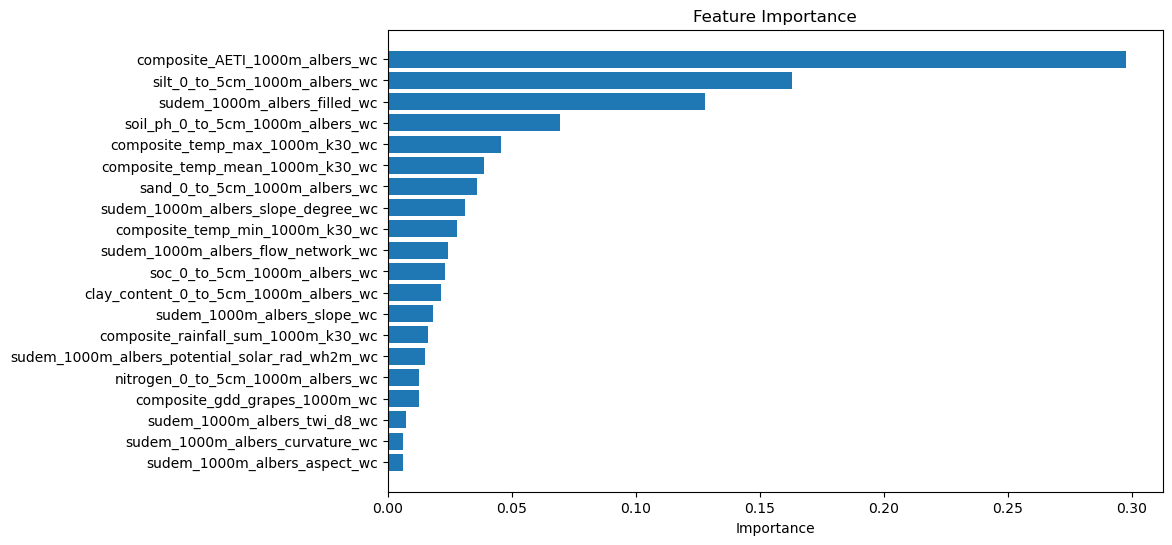

In [51]:
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_features)), sorted_features)
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

In [163]:
# list of important features (top 5)

# This list is from the model that was trained with the non-standardised data
# (5) 'composite_temp_max_1000m_k30_wc'
# (4) 'soil_ph_0_to_5cm_1000m_albers_wc'
# (3) 'sudem_1000m_albers_filled_wc'
# (2) 'silt_0_to_5cm_1000m_albers_wc'
# (1) 'composite_AETI_1000m_albers_wc'


# This list is from the model that was trained with the standardised data
# (5) 'sand_0_to_5cm_1000m_albers_wc_fuzzy_linear'
# (4) 'silt_0_to_5cm_1000m_albers_wc_fuzzy_linear'
# (3) 'soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear'
# (2) 'sudem_1000m_albers_filled_wc_fuzzy_linear'
# (1) 'composite_AETI_1000m_albers_wc_fuzzy_linear'

In [52]:
# top 5 features from the model that was trained with non-standardised data
top_features = ['composite_temp_max_1000m_k30_wc', 'soil_ph_0_to_5cm_1000m_albers_wc', 'sudem_1000m_albers_filled_wc', 'silt_0_to_5cm_1000m_albers_wc', 'composite_AETI_1000m_albers_wc']

# top 5 features from the model that was trained with standardised data
# top_features = ['sand_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'silt_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'composite_AETI_1000m_albers_wc_fuzzy_linear', 'sudem_1000m_albers_filled_wc_fuzzy_linear']   



In [53]:
# only get the top features from the training and testing data
X_train_top_features = X_train[top_features]
X_test_top_features = X_test[top_features]

X_train_top_features.head()
X_test_top_features.head()

# only get the top features from the points that are used for prediction
new_locations_df_top_features = new_locations_df[top_features]

,composite_temp_max_1000m_k30_wc,soil_ph_0_to_5cm_1000m_albers_wc,sudem_1000m_albers_filled_wc,silt_0_to_5cm_1000m_albers_wc,composite_AETI_1000m_albers_wc
18351,22.960733,63.000000,52.553494,86.459610,4102.985352
63308,23.613295,77.576752,932.659973,167.365418,2911.355957
61822,22.985672,66.026741,197.918564,184.764374,5471.569824
85828,23.115517,77.000000,1168.909302,181.118637,2231.010742
67091,24.465687,76.516464,438.607910,148.141327,1770.658691


,composite_temp_max_1000m_k30_wc,soil_ph_0_to_5cm_1000m_albers_wc,sudem_1000m_albers_filled_wc,silt_0_to_5cm_1000m_albers_wc,composite_AETI_1000m_albers_wc
66096,23.004803,65.515961,238.789551,163.691940,4463.497070
39498,24.953625,71.985573,502.960358,151.870132,8159.201172
24632,25.215847,70.487572,136.786865,119.814613,8846.524414
54482,21.723415,76.287926,1027.325073,176.341217,4198.377441
56581,23.116348,70.281380,144.024124,140.520859,3740.723633


In [54]:
# check for duplicates between training and testing data
X_train_top_features.duplicated().sum()
X_test_top_features.duplicated().sum()

# Create complete datasets for training and testing
top_features_train_data = pd.concat([X_train_top_features, y_train], axis=1)
top_features_test_data = pd.concat([X_test_top_features, y_test], axis=1)

top_features_train_data.shape
top_features_test_data.shape

# Check for duplicates between training and testing data
# top_features_duplicates_df = pd.concat([top_features_train_data, top_features_test_data])
duplicates = pd.concat([top_features_train_data, top_features_test_data]).duplicated().sum()

duplicates

0

0

(73770, 6)

(18443, 6)

0

In [55]:
# Retraining the model with only the top features
# y_train does not change, since that is my prediction target (predictor variable/ target variable)

xgb_model_top = XGBRegressor(objective='reg:logistic', random_state=42)
xgb_model_top.fit(X_train_top_features, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, objective='reg:logistic', ...)

In [56]:
# Evaluate the new model
y_pred_top_features = xgb_model_top.predict(X_test_top_features)

mae = mean_absolute_error(y_test, y_pred_top_features)
mse_top = mean_squared_error(y_test, y_pred_top_features)
r2_top = r2_score(y_test, y_pred_top_features)

print(f"MAE (top features): {mae}")
print(f"MSE (top features): {mse_top}")
print(f"R2 (top features): {r2_top}")

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# model results from with top features from non-standardised dataset
# MAE (top features): 0.07960100764449218
# MSE (top features): 0.038319969479073644
# R2 (top features): 0.8467128872871399

# model results with top features from standardised dataset
# MAE (top features): 0.08452244689630961
# MSE (top features): 0.03966760123362389
# R2 (top features): 0.8413287997245789

MAE (top features): 0.07960100764449218
MSE (top features): 0.038319969479073644
R2 (top features): 0.8467128872871399


In [57]:
# Compare with original model's performance

# Make predictions on new locations
suitability_scores_top_features = xgb_model_top.predict(new_locations_df_top_features)

# Add predictions to the new_locations dataframe
new_locations_df_top_features['suitability_score_top_features'] = suitability_scores_top_features
new_locations_df_top_features['POINT_X'] = original_point_x
new_locations_df_top_features['POINT_Y'] = original_point_y

In [58]:
new_locations_df_top_features.head()
new_locations_df_top_features['suitability_score_top_features'].describe()

,composite_temp_max_1000m_k30_wc,soil_ph_0_to_5cm_1000m_albers_wc,sudem_1000m_albers_filled_wc,silt_0_to_5cm_1000m_albers_wc,composite_AETI_1000m_albers_wc,suitability_score_top_features,POINT_X,POINT_Y
2,23.882336,69.261879,24.433515,84.575073,923.917419,0.008094,17.901065,-32.989947
3,23.707560,69.706451,25.709961,66.374649,878.122559,0.002573,17.910862,-32.989976
4,23.522215,68.576538,49.180881,60.291542,1146.293945,0.000141,17.920659,-32.990006
5,23.490379,70.335014,98.710983,55.848217,1421.013672,0.001016,17.930456,-32.990036
6,23.549480,66.538101,61.861515,51.885803,1330.613525,0.000495,17.940253,-32.990065


count    1.294230e+05
mean     8.626741e-02
std      2.204782e-01
min      3.737580e-07
25%      8.674146e-05
50%      1.239295e-03
75%      2.427302e-02
max      9.996265e-01
Name: suitability_score_top_features, dtype: float64

In [183]:
# Saving results for non-standardised data
new_locations_df_top_features.to_csv('../output_points_data/prediction_on_important_features/wc_predicted_suitability_important_features_no_ndvi-rivers-roads.csv', index=False)    

# Saving results for standardised data
# new_locations_df_top_features.to_csv('../output_points_data/prediction_on_important_features/wc_predicted_suitability_important_features_no_ndvi-rivers-roads_fuzzy_linear.csv', index=False)    